In [2]:
# Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
# Načtení datasetu
df = pd.read_csv("../data/mzdy.csv")
df = df.dropna()
df_numeric = df.select_dtypes(include=[np.number])

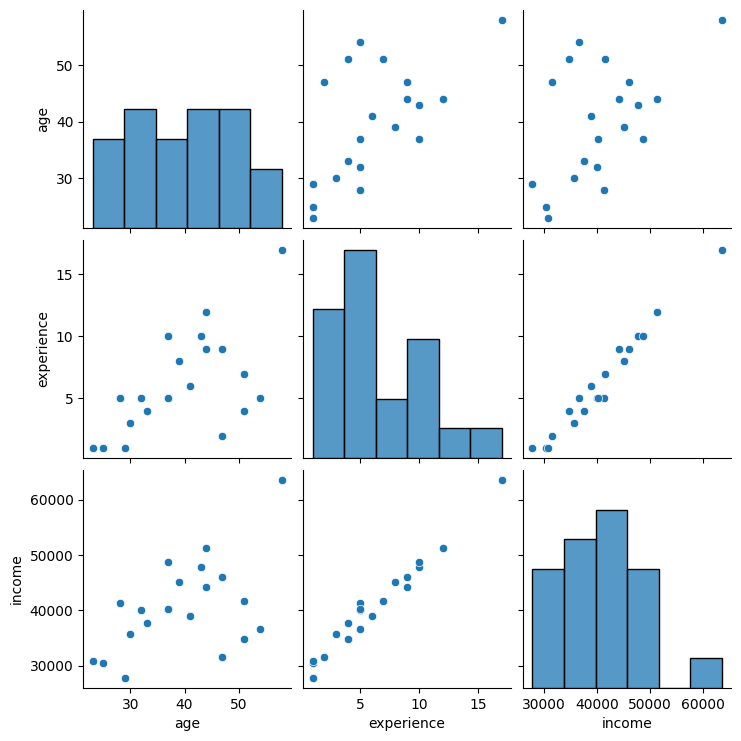

In [16]:
# Základní mřížka grafů
sns.pairplot(df_numeric)

Text(0.5, 1.0, 'Korelační matice proměnných')

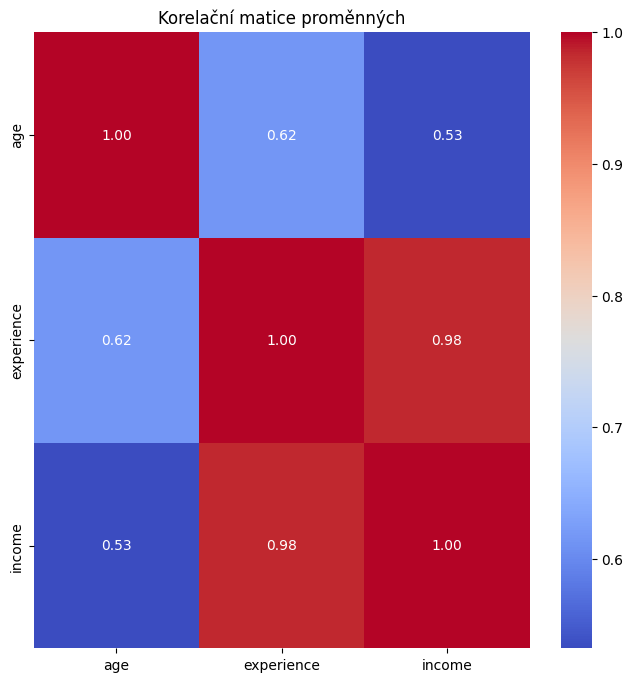

In [ ]:
# Korelační matice proměnných
corr_matrix = df_numeric.corr()
corr_matrix
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelační matice proměnných")

In [33]:
# Vytvoření modelu
X = sm.add_constant(df_numeric[["experience", "age"]])
y = df_numeric["income"]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 income   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     366.5
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           1.05e-14
Time:                        20:45:05   Log-Likelihood:                -170.81
No. Observations:                  20   AIC:                             347.6
Df Residuals:                      17   BIC:                             350.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.126e+04   1306.437     23.929      0.000    2.85e+04     3.4e+04
experience  2162.4042     94.770     22.817      0.000    1962.457    2362.351
age          -99.1954     38.979     -2.545      0.021    -181.433     -16.958
==============================================================================
Omnibus:                        0.799   Durbin-Watson:                   1.628
Prob(Omnibus):                  0.671   Jarque-Bera (JB):                0.695
Skew:                          -0.404   Prob(JB):                        0.707
Kurtosis:                       2.575   Cond. No.                         180.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

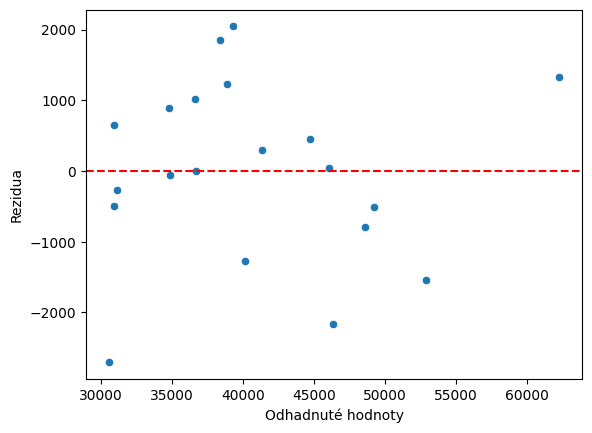

In [37]:
# Kontrola heteroskedasticity
residuals = results.resid
fitted = results.fittedvalues

# Graf
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Odhadnuté hodnoty")
plt.ylabel("Rezidua")
plt.show()

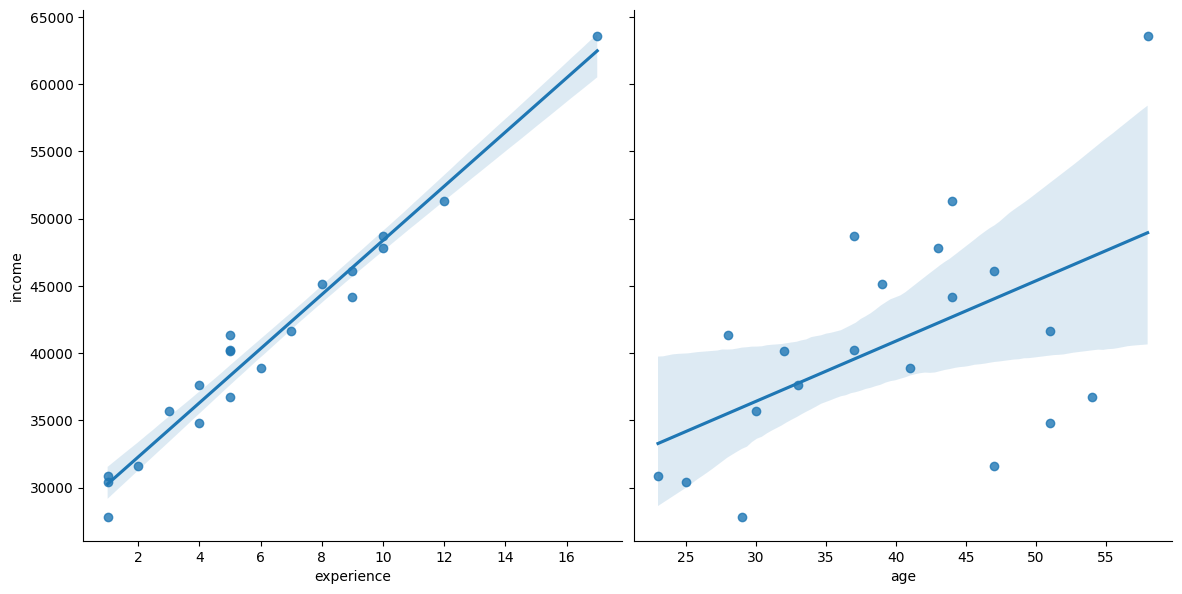

In [44]:
# Graf modelu
sns.pairplot(df_numeric, x_vars=["experience", "age"], y_vars="income", kind='reg', height=6)

In [47]:
# F-statistika
print(f"F-statistika: {results.fvalue}")
print(f"p-hodnota F-testu: {results.f_pvalue}")

F-statistika: 366.5462909391462
p-hodnota F-testu: 1.0479472748289526e-14


In [49]:
print(f"R^2: {results.rsquared}")
print(f"Adjusted R^2: {results.rsquared_adj}")

R^2: 0.9773361310180796
Adjusted R^2: 0.9746697934907949


In [50]:
print(f"p-hodnota: {results.pvalues}")

p-hodnota: const         1.567157e-14
experience    3.437448e-14
age           2.092977e-02
dtype: float64
